# ResNet50V2 para clasificación de riesgo de glaucoma — Chákṣu

Este notebook implementa el primer experimento de Transfer Learning y Fine-Tuning para la clasificación binaria de riesgo de glaucoma utilizando ResNet50V2.

Clases funcionales del proyecto:

- 0 = LOW_RISK
- 1 = HIGH_RISK

Correspondencia con las etiquetas originales de Chákṣu:

- NORMAL → LOW_RISK
- GLAUCOMA SUSPECT → HIGH_RISK

El experimento utiliza las mismas particiones, preprocesamiento geométrico, política de Data Augmentation y estrategia de ponderación de clases definidas previamente.

Etapas:

1. Verificación del entorno de ejecución y GPU.
2. Carga de las particiones congeladas.
3. Reconstrucción del pipeline común.
4. Preprocesamiento específico de ResNet50V2.
5. Construcción del modelo con pesos ImageNet.
6. Verificación de memoria mediante un forward pass.
7. Transfer Learning.
8. Fine-Tuning.
9. Evaluación sobre Validation.
10. Selección del umbral de decisión utilizando exclusivamente Validation.
11. Evaluación final sobre Test.

## 1. Verificación del entorno y GPU

Comprobación de las versiones de Python y TensorFlow, detección de dispositivos de aceleración por hardware (GPU) y configuración de crecimiento dinámico de memoria VRAM (`set_memory_growth`) para evitar la reserva total inmediata de la memoria gráfica.

In [1]:
from pathlib import Path
import sys
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU disponibles:", gpus)

if not gpus:
    raise RuntimeError(
        "No se detectó ninguna GPU. "
        "No continuar con el entrenamiento."
    )

for gpu in gpus:
    tf.config.experimental.set_memory_growth(
        gpu,
        True
    )


I0000 00:00:1790693816.928337   44716 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790693817.839834   44716 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1790693819.498500   44716 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Python: 3.12.14 (main, Sep 24 2026, 17:57:43) [Clang 22.1.3 ]
TensorFlow: 2.21.0
GPU disponibles: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1790693821.621764   44716 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 2. Configuración general y rutas

Definición de las rutas del proyecto en el entorno Linux/WSL, directorios de salida para pesos del modelo (`models/glaucoma/resnet50v2`) y métricas experimentales (`results/glaucoma/resnet50v2`), fijación de semilla común (`RANDOM_STATE = 42`) y parámetros de resolución y tamaño de lote (`IMAGE_SIZE = 384`, `BATCH_SIZE = 8`).

In [2]:
PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
CHAKSU_ROOT = (
    PROJECT_ROOT
    / "datasets"
    / "glaucoma"
    / "chaksu"
)
METADATA_DIR = CHAKSU_ROOT / "metadata"
SPLITS_PATH = (
    METADATA_DIR
    / "chaksu_splits.csv"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "models"
    / "glaucoma"
    / "resnet50v2"
)
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "glaucoma"
    / "resnet50v2"
)

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

IMAGE_SIZE = 384
BATCH_SIZE = 8
RANDOM_STATE = 42

NUM_PARALLEL_CALLS = 2
PREFETCH_BUFFER = 1

tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print("Proyecto:", PROJECT_ROOT)
print("Splits:", SPLITS_PATH)
print("Modelos:", MODEL_DIR)
print("Resultados:", RESULTS_DIR)
print(
    "\nExiste chaksu_splits.csv:",
    SPLITS_PATH.exists()
)

Proyecto: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan
Splits: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/datasets/glaucoma/chaksu/metadata/chaksu_splits.csv
Modelos: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2
Resultados: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/glaucoma/resnet50v2

Existe chaksu_splits.csv: True


## 3. Carga y verificación de particiones congeladas

Lectura del archivo maestro de particiones `chaksu_splits.csv` y validación estricta de integridad (conteo de muestras y balance de clases exacto por partición) para verificar la integridad de las particiones y favorecer la reproducibilidad experimental, impidiendo cualquier fuga o desalineación de datos.

In [3]:
df = pd.read_csv(
    SPLITS_PATH
)
train_df = df[
    df["experimental_split"] == "train"
].copy()
val_df = df[
    df["experimental_split"] == "validation"
].copy()
test_df = df[
    df["experimental_split"] == "test"
].copy()

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

assert len(train_df) == 807
assert len(val_df) == 202
assert len(test_df) == 336
assert train_df["label"].value_counts().to_dict() == {
    0: 697,
    1: 110
}
assert val_df["label"].value_counts().to_dict() == {
    0: 175,
    1: 27
}
assert test_df["label"].value_counts().to_dict() == {
    0: 285,
    1: 51
}
print("Splits congelados verificados correctamente.")


Train: 807
Validation: 202
Test: 336
Splits congelados verificados correctamente.


## 4. Reutilización del pipeline geométrico y Data Augmentation

Incorporación idéntica del pipeline geométrico previamente validado (detección de FOV por contorno convexo, recorte con margen, padding cuadrado y redimensionamiento a 384 × 384), la capa de Data Augmentation conservadora para Train (flip horizontal, rotación de ±11°, zoom isotrópico de ±10% y contraste de ±10%) y el cálculo de pesos balanceados de clase exclusivamente a partir de Train.

In [4]:
def resolver_ruta(ruta_relativa):
    return PROJECT_ROOT / Path(ruta_relativa)

def detectar_fov(imagen_rgb, umbral=10):
    gris = cv2.cvtColor(
        imagen_rgb,
        cv2.COLOR_RGB2GRAY
    )
    _, mascara_inicial = cv2.threshold(
        gris,
        umbral,
        255,
        cv2.THRESH_BINARY
    )
    kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (15, 15)
    )
    mascara_limpia = cv2.morphologyEx(
        mascara_inicial,
        cv2.MORPH_CLOSE,
        kernel
    )
    num_labels, labels, stats, _ = (
        cv2.connectedComponentsWithStats(
            mascara_limpia,
            connectivity=8
        )
    )
    if num_labels <= 1:
        return None, None
    areas = stats[
        1:,
        cv2.CC_STAT_AREA
    ]
    mayor_componente = (
        1 + np.argmax(areas)
    )
    mascara_componente = (
        labels == mayor_componente
    ).astype(np.uint8) * 255
    contornos, _ = cv2.findContours(
        mascara_componente,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
    if len(contornos) == 0:
        return None, None
    contorno_principal = max(
        contornos,
        key=cv2.contourArea
    )
    hull = cv2.convexHull(
        contorno_principal
    )
    mascara_fov = np.zeros_like(
        mascara_componente
    )
    cv2.fillConvexPoly(
        mascara_fov,
        hull,
        255
    )
    x, y, w, h = cv2.boundingRect(
        hull
    )
    return mascara_fov, (x, y, w, h)

def ampliar_bbox(
    bbox,
    image_width,
    image_height,
    margen=0.02
):
    x, y, w, h = bbox
    margen_x = int(w * margen)
    margen_y = int(h * margen)
    x1 = max(
        0,
        x - margen_x
    )
    y1 = max(
        0,
        y - margen_y
    )
    x2 = min(
        image_width,
        x + w + margen_x
    )
    y2 = min(
        image_height,
        y + h + margen_y
    )
    return x1, y1, x2, y2

def recortar_fov(imagen_rgb):
    mascara, bbox = detectar_fov(
        imagen_rgb
    )
    if bbox is None:
        return imagen_rgb, None
    imagen_enmascarada = cv2.bitwise_and(
        imagen_rgb,
        imagen_rgb,
        mask=mascara
    )
    alto, ancho = imagen_rgb.shape[:2]
    x1, y1, x2, y2 = ampliar_bbox(
        bbox,
        image_width=ancho,
        image_height=alto,
        margen=0.02
    )
    recorte = imagen_enmascarada[
        y1:y2,
        x1:x2
    ]
    return recorte, (
        x1,
        y1,
        x2,
        y2
    )

def padding_cuadrado(imagen_rgb):
    alto, ancho = imagen_rgb.shape[:2]
    lado = max(alto, ancho)
    imagen_cuadrada = np.zeros(
        (lado, lado, 3),
        dtype=imagen_rgb.dtype
    )
    y_offset = (lado - alto) // 2
    x_offset = (lado - ancho) // 2
    imagen_cuadrada[
        y_offset:y_offset + alto,
        x_offset:x_offset + ancho
    ] = imagen_rgb
    return imagen_cuadrada

def redimensionar_imagen(
    imagen_rgb,
    size=IMAGE_SIZE
):
    return cv2.resize(
        imagen_rgb,
        (size, size),
        interpolation=cv2.INTER_AREA
    )

def preprocesar_geometria(
    imagen_rgb,
    size=IMAGE_SIZE
):
    recorte, bbox = recortar_fov(
        imagen_rgb
    )
    if bbox is None:
        raise ValueError(
            "No se pudo detectar el campo de visión retinal."
        )
    imagen_cuadrada = padding_cuadrado(
        recorte
    )
    imagen_resize = redimensionar_imagen(
        imagen_cuadrada,
        size=size
    )
    return imagen_resize, bbox

def cargar_y_preprocesar_python(
    image_path,
    label
):
    ruta = resolver_ruta(
        image_path.decode("utf-8")
    )
    with Image.open(ruta) as img:
        imagen_rgb = np.array(
            img.convert("RGB")
        )
    procesada, _ = preprocesar_geometria(
        imagen_rgb,
        size=IMAGE_SIZE
    )
    procesada = procesada.astype(
        np.float32
    )
    return procesada, np.float32(label)

def cargar_y_preprocesar_tf(
    image_path,
    label
):
    imagen, etiqueta = tf.numpy_function(
        func=cargar_y_preprocesar_python,
        inp=[
            image_path,
            label
        ],
        Tout=[
            tf.float32,
            tf.float32
        ]
    )
    imagen.set_shape(
        [IMAGE_SIZE, IMAGE_SIZE, 3]
    )
    etiqueta.set_shape([])
    return imagen, etiqueta

def crear_dataset_base(
    dataframe,
    shuffle=False
):
    rutas = dataframe[
        "image_path"
    ].astype(str).values
    etiquetas = dataframe[
        "label"
    ].astype(np.float32).values
    ds = tf.data.Dataset.from_tensor_slices(
        (
            rutas,
            etiquetas
        )
    )
    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=RANDOM_STATE,
            reshuffle_each_iteration=True
        )
    ds = ds.map(
        cargar_y_preprocesar_tf,
        num_parallel_calls=NUM_PARALLEL_CALLS
    )
    return ds

data_augmentation = tf.keras.Sequential(
    [
        tf.keras.layers.RandomFlip(
            "horizontal"
        ),
        tf.keras.layers.RandomRotation(
            factor=0.03,
            fill_mode="constant",
            fill_value=0.0
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.10, 0.10),
            fill_mode="constant",
            fill_value=0.0
        ),
        tf.keras.layers.RandomContrast(
            factor=0.10
        )
    ],
    name="data_augmentation"
)

def aplicar_augmentation(
    imagen,
    etiqueta
):
    imagen = data_augmentation(
        imagen,
        training=True
    )
    return imagen, etiqueta

clases = np.array(
    sorted(
        train_df["label"].unique()
    )
)
pesos = compute_class_weight(
    class_weight="balanced",
    classes=clases,
    y=train_df["label"].values
)
class_weights = {
    int(clase): float(peso)
    for clase, peso in zip(
        clases,
        pesos
    )
}
print(class_weights)

{0: 0.578909612625538, 1: 3.668181818181818}


W0000 00:00:1790693833.650821   44716 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1790693834.047940   44716 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9217 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:01:00.0, compute capability: 12.0a


## 5. Preprocesamiento específico de ResNet50V2

Definición de la función de escalamiento de píxeles mediante `preprocess_input` de `tf.keras.applications.resnet_v2`. Esta transformación mapea las intensidades continuas de `[0, 255]` al rango centrado en cero `[-1, 1]` esperado por la arquitectura ResNetV2 sin dividir previamente por 255.

In [5]:
def preprocess_resnet50v2(
    imagen,
    etiqueta
):
    imagen = tf.keras.applications.resnet_v2.preprocess_input(
        imagen
    )
    return imagen, etiqueta

## 6. Crear datasets para ResNet50V2

Integración del pipeline completo con `tf.data`: Data Augmentation exclusiva para Train, escalamiento específico `preprocess_resnet50v2` para todos los subconjuntos, empaquetado en lotes de tamaño 8 (`batch(BATCH_SIZE)`) y precarga controlada con `prefetch(PREFETCH_BUFFER)` para limitar el consumo de memoria durante el procesamiento.

In [6]:
train_ds = crear_dataset_base(
    train_df,
    shuffle=True
)
val_ds = crear_dataset_base(
    val_df,
    shuffle=False
)
test_ds = crear_dataset_base(
    test_df,
    shuffle=False
)

train_ds = train_ds.map(
    aplicar_augmentation,
    num_parallel_calls=NUM_PARALLEL_CALLS
)
train_ds = train_ds.map(
    preprocess_resnet50v2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)
val_ds = val_ds.map(
    preprocess_resnet50v2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)
test_ds = test_ds.map(
    preprocess_resnet50v2,
    num_parallel_calls=NUM_PARALLEL_CALLS
)

train_ds = (
    train_ds
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)
val_ds = (
    val_ds
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)
test_ds = (
    test_ds
    .batch(BATCH_SIZE)
    .prefetch(PREFETCH_BUFFER)
)

## 7. Verifica el rango

Inspección del primer lote generado por `train_ds` para comprobar que las dimensiones espaciales coincidan con `(8, 384, 384, 3)` y que los valores mínimo y máximo de píxeles se ubiquen en el rango esperado `[-1, 1]`.

In [7]:
for images, labels in train_ds.take(1):
    print(
        "Shape:",
        images.shape
    )
    print(
        "Min:",
        float(
            tf.reduce_min(images)
        )
    )
    print(
        "Max:",
        float(
            tf.reduce_max(images)
        )
    )
    print(
        "Labels:",
        labels.numpy()
    )


Shape: (8, 384, 384, 3)
Min: -1.0
Max: 1.0
Labels: [0. 0. 0. 0. 0. 0. 0. 0.]


## 8. Construimos ResNet50V2

Instanciación del backbone preentrenado `ResNet50V2` sin la capa clasificadora superior (`include_top=False`), congelamiento de sus capas base (`base_model.trainable = False`) para la primera fase de Transfer Learning, y ensamblaje de la cabeza de clasificación binaria: `GlobalAveragePooling2D`, regularización `Dropout(0.30)` y neurona de salida única con activación `sigmoid` para estimar el score de riesgo (`HIGH_RISK`).

In [8]:
base_model = tf.keras.applications.ResNet50V2(
    include_top=False,
    weights="imagenet",
    input_shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    )
)
base_model.trainable = False

inputs = tf.keras.Input(
    shape=(
        IMAGE_SIZE,
        IMAGE_SIZE,
        3
    )
)
x = base_model(
    inputs,
    training=False
)
x = tf.keras.layers.GlobalAveragePooling2D()(
    x
)
x = tf.keras.layers.Dropout(
    0.30
)(
    x
)
outputs = tf.keras.layers.Dense(
    1,
    activation="sigmoid"
)(
    x
)
model = tf.keras.Model(
    inputs,
    outputs,
    name="ResNet50V2_Chaksu"
)


## 9. Verifica parámetros

Resumen estructural del modelo y conteo discriminado de parámetros totales, entrenables (correspondientes a la capa densa de clasificación) y no entrenables (backbone convolucional congelado).

In [9]:
model.summary()

total_params = model.count_params()
trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)
non_trainable_params = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)
print(
    "Parámetros totales:",
    f"{total_params:,}"
)
print(
    "Entrenables:",
    f"{trainable_params:,}"
)
print(
    "No entrenables:",
    f"{non_trainable_params:,}"
)


Model: "ResNet50V2_Chaksu"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 384, 384, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 12, 12, 2048)   │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         2,049 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,566,849 (89.90 MB)

 Trainable params: 2,049 (8.00 KB)

 Non-trainable params: 23,564,800 (89.89 MB)

Parámetros totales: 23,566,849
Entrenables: 2,049
No entrenables: 23,564,800


## 10. Antes de entrenar: prueba de memoria

Pase hacia adelante (*forward pass*) de prueba con un lote completo de entrenamiento `(8, 384, 384, 3)` para confirmar la compatibilidad de memoria VRAM en la GPU, la correcta asignación de dispositivo y la emisión de scores de salida preliminares sin desbordamientos de memoria (*OOM*).

In [10]:
for images, labels in train_ds.take(1):
    predictions = model(
        images,
        training=False
    )
    print(
        "Entrada:",
        images.shape
    )
    print(
        "Salida:",
        predictions.shape
    )
    print(
        "Dispositivo:",
        predictions.device
    )
    print(
        "Primeras predicciones:"
    )
    print(
        predictions.numpy().flatten()
    )


I0000 00:00:1790690590.995047   33963 cuda_dnn.cc:461] Loaded cuDNN version 92600


Entrada: (8, 384, 384, 3)
Salida: (8, 1)
Dispositivo: /job:localhost/replica:0/task:0/device:GPU:0
Primeras predicciones:
[0.20356607 0.11530586 0.10585365 0.13680543 0.1837162  0.17057782
 0.08645738 0.11710536]


## 11. Fase 1 — Transfer Learning

En esta primera fase se mantiene completamente congelado el backbone preentrenado ResNet50V2 y se entrena únicamente la nueva cabeza de clasificación binaria.

El entrenamiento utiliza:

- Binary Cross-Entropy como función de pérdida.
- Adam como optimizador.
- Learning rate inicial de 1e-3.
- Ponderación de clases calculada exclusivamente sobre Train.
- Validation para supervisar el entrenamiento.
- Early Stopping y Model Checkpoint basados en `val_loss`.
- Reducción automática del learning rate si la pérdida de validación deja de mejorar.

Las métricas calculadas durante el entrenamiento incluyen ROC-AUC, PR-AUC, Precision, Recall y Binary Accuracy. Debido al desbalance entre clases, Accuracy se conserva únicamente como métrica complementaria.

El conjunto Test permanece completamente aislado durante esta fase.

### 11.1. Configuración del entrenamiento

Definición de hiperparámetros de la fase inicial (`INITIAL_LR = 1e-3`, `MAX_EPOCHS_TRANSFER = 20`, `EARLY_STOPPING_PATIENCE = 5`) y rutas de persistencia para el checkpoint del mejor modelo y el registro de métricas por época.

In [ ]:
INITIAL_LR = 1e-3

MAX_EPOCHS_TRANSFER = 20

EARLY_STOPPING_PATIENCE = 5

TRANSFER_MODEL_PATH = (

    MODEL_DIR

    / "resnet50v2_transfer_best.keras"

)

TRANSFER_LOG_PATH = (

    RESULTS_DIR

    / "resnet50v2_transfer_log.csv"

)



print(

    "Backbone entrenable:",

    base_model.trainable

)

print(

    "Learning rate inicial:",

    INITIAL_LR

)

print(

    "Máximo de epochs:",

    MAX_EPOCHS_TRANSFER

)

print(

    "Checkpoint:",

    TRANSFER_MODEL_PATH

)



### 11.2. Compilar el modelo

Compilación con optimizador Adam, función de pérdida `BinaryCrossentropy` y conjunto de métricas para clasificación desbalanceada: Accuracy, ROC-AUC, PR-AUC, Precision y Recall.

In [12]:
model.compile(

    optimizer=tf.keras.optimizers.Adam(

        learning_rate=INITIAL_LR

    ),

    loss=tf.keras.losses.BinaryCrossentropy(),

    metrics=[

        tf.keras.metrics.BinaryAccuracy(

            name="accuracy",

            threshold=0.5

        ),

        tf.keras.metrics.AUC(

            name="roc_auc",

            curve="ROC"

        ),

        tf.keras.metrics.AUC(

            name="pr_auc",

            curve="PR"

        ),

        tf.keras.metrics.Precision(

            name="precision",

            thresholds=0.5

        ),

        tf.keras.metrics.Recall(

            name="recall",

            thresholds=0.5

        )

    ]

)



print("Modelo compilado correctamente.")



Modelo compilado correctamente.


### 11.3. Callbacks

Configuración de `ModelCheckpoint`, `EarlyStopping`, `ReduceLROnPlateau`, `CSVLogger` y `TerminateOnNaN` basados en la minimización de `val_loss` para evitar el sobreajuste y preservar los mejores pesos.

In [13]:
callbacks_transfer = [

    tf.keras.callbacks.ModelCheckpoint(

        filepath=TRANSFER_MODEL_PATH,

        monitor="val_loss",

        mode="min",

        save_best_only=True,

        verbose=1

    ),

    tf.keras.callbacks.EarlyStopping(

        monitor="val_loss",

        mode="min",

        patience=EARLY_STOPPING_PATIENCE,

        restore_best_weights=True,

        verbose=1

    ),

    tf.keras.callbacks.ReduceLROnPlateau(

        monitor="val_loss",

        mode="min",

        factor=0.2,

        patience=2,

        min_lr=1e-6,

        verbose=1

    ),

    tf.keras.callbacks.CSVLogger(

        filename=TRANSFER_LOG_PATH,

        append=False

    ),

    tf.keras.callbacks.TerminateOnNaN()

]



print(

    "Callbacks configurados:",

    len(callbacks_transfer)

)



Callbacks configurados: 5


## 12. Entrenamiento de la cabeza clasificadora

Se entrena únicamente la cabeza de clasificación mientras el backbone ResNet50V2 permanece congelado.

La ponderación de clases se aplica exclusivamente a las muestras de Train. Validation conserva su distribución natural y no recibe Data Augmentation ni ponderación artificial.

El entrenamiento puede finalizar antes de las 20 épocas si `val_loss` deja de mejorar según el criterio de Early Stopping.

In [14]:
import time

inicio_transfer = time.perf_counter()

history_transfer = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_TRANSFER,
    class_weight=class_weights,
    callbacks=callbacks_transfer,
    shuffle=False,
    verbose=1
)

fin_transfer = time.perf_counter()
tiempo_transfer_seg = (
    fin_transfer - inicio_transfer
)

print(
    "\nTiempo total Transfer Learning:",
    f"{tiempo_transfer_seg / 60:.2f} minutos"
)

Epoch 1/20


I0000 00:00:1790690617.791386   34112 service.cc:153] XLA service 0x73dd7c060700 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790690617.791455   34112 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790690618.053472   34112 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  1/101 ━━━━━━━━━━━━━━━━━━━━ 25:44 15s/step - accuracy: 0.8750 - loss: 0.8713 - pr_auc: 1.0000 - precision: 0.0000e+00 - recall: 0.0000e+00 - roc_auc: 1.0000

I0000 00:00:1790690628.385185   34112 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.5762 - loss: 0.7414 - pr_auc: 0.1395 - precision: 0.1608 - recall: 0.5000 - roc_auc: 0.5341
Epoch 1: val_loss improved from None to 0.77569, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_transfer_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_transfer_best.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 82s 665ms/step - accuracy: 0.5762 - loss: 0.7414 - pr_auc: 0.1395 - precision: 0.1608 - recall: 0.5000 - roc_auc: 0.5341 - val_accuracy: 0.3564 - val_loss: 0.7757 - val_pr_auc: 0.2927 - val_precision: 0.1497 - val_recall: 0.8148 - val_roc_auc: 0.6714 - learning_rate: 0.0010
Epoch 2/20
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6283 - loss: 0.6489 - pr_auc: 0.2472 - precision: 0.2121 - recall: 0.6364 - roc_auc: 0.6752
Epoch 2: val_loss improved from 0.77569 to 0.76135, saving model to /mnt/c/Users/

## 13. Guardar el historial

Almacenamiento tabular estructurado del historial de métricas por época (`resnet50v2_transfer_history.csv`) y visualización de la evolución completa de las pérdidas y métricas en Train y Validation.

In [15]:
history_transfer_df = pd.DataFrame(

    history_transfer.history

)

history_transfer_df.index = (

    np.arange(

        1,

        len(history_transfer_df) + 1

    )

)

history_transfer_df.index.name = "epoch"



HISTORY_TRANSFER_PATH = (

    RESULTS_DIR

    / "resnet50v2_transfer_history.csv"

)



history_transfer_df.to_csv(

    HISTORY_TRANSFER_PATH

)



print(

    "Historial guardado en:",

    HISTORY_TRANSFER_PATH

)



display(

    history_transfer_df

)



Historial guardado en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/glaucoma/resnet50v2/resnet50v2_transfer_history.csv


,accuracy,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc,learning_rate
epoch,,,,,,,,,,,,,
1,0.576208,0.741428,0.139518,0.160819,0.500000,0.534140,0.356436,0.775692,0.292654,0.149660,0.814815,0.671429,0.001000
2,0.628253,0.648895,0.247221,0.212121,0.636364,0.675218,0.465347,0.761352,0.361457,0.190840,0.925926,0.735979,0.001000
3,0.680297,0.588225,0.357895,0.256579,0.709091,0.749120,0.826733,0.428164,0.383069,0.318182,0.259259,0.770370,0.001000
4,0.706320,0.591153,0.318885,0.270758,0.681818,0.758517,0.772277,0.513577,0.434302,0.327273,0.666667,0.788783,0.001000
5,0.726146,0.551807,0.381716,0.290566,0.700000,0.795741,0.628713,0.622601,0.440170,0.239130,0.814815,0.803069,0.001000
6,0.713755,0.517138,0.431271,0.296296,0.800000,0.835131,0.841584,0.417704,0.433478,0.419355,0.481481,0.802434,0.000200
7,0.769517,0.544295,0.407932,0.340336,0.736364,0.812299,0.772277,0.495819,0.438482,0.320755,0.629630,0.805820,0.000200
8,0.712515,0.528698,0.449297,0.292517,0.781818,0.817112,0.797030,0.460234,0.440564,0.347826,0.592593,0.808677,0.000200
9,0.714994,0.532662,0.428422,0.287234,0.736364,0.812560,0.801980,0.457611,0.440382,0.355556,0.592593,0.807725,0.000040


## 14. Curvas de entrenamiento

### 14.1. Curva de pérdida (Binary Cross-Entropy)

Visualización de la evolución de la función de pérdida en Train y Validation para supervisar la convergencia y la ausencia de sobreajuste temprano.

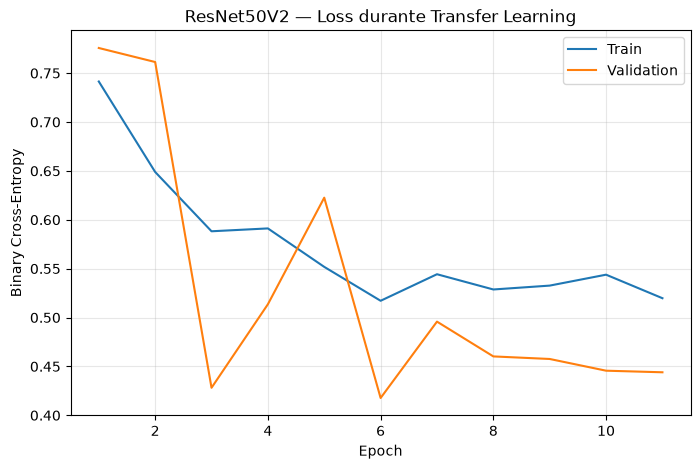

In [16]:
plt.figure(

    figsize=(8, 5)

)

plt.plot(

    history_transfer_df.index,

    history_transfer_df["loss"],

    label="Train"

)

plt.plot(

    history_transfer_df.index,

    history_transfer_df["val_loss"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("Binary Cross-Entropy")

plt.title(

    "ResNet50V2 — Loss durante Transfer Learning"

)

plt.legend()

plt.grid(alpha=0.3)

plt.show()



### 14.2. Curva de discriminación (ROC-AUC)

Evolución del área bajo la curva ROC (*Receiver Operating Characteristic*) a lo largo de las épocas en los subconjuntos Train y Validation.

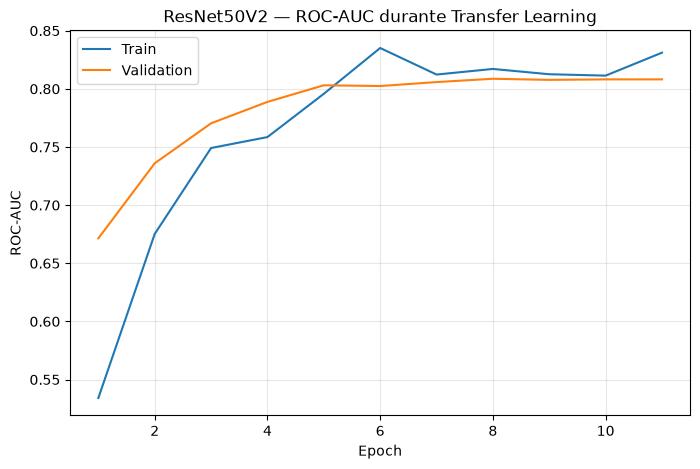

In [17]:
plt.figure(

    figsize=(8, 5)

)

plt.plot(

    history_transfer_df.index,

    history_transfer_df["roc_auc"],

    label="Train"

)

plt.plot(

    history_transfer_df.index,

    history_transfer_df["val_roc_auc"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("ROC-AUC")

plt.title(

    "ResNet50V2 — ROC-AUC durante Transfer Learning"

)

plt.legend()

plt.grid(alpha=0.3)

plt.show()



### 14.3. Curva de precisión-exhaustividad (PR-AUC)

Evolución del área bajo la curva Precision-Recall, métrica crítica para evaluar el rendimiento sobre la clase minoritaria (`HIGH_RISK`).

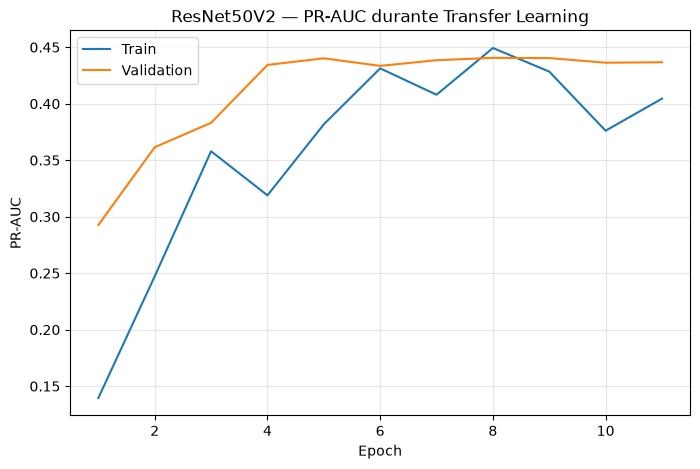

In [18]:
plt.figure(

    figsize=(8, 5)

)

plt.plot(

    history_transfer_df.index,

    history_transfer_df["pr_auc"],

    label="Train"

)

plt.plot(

    history_transfer_df.index,

    history_transfer_df["val_pr_auc"],

    label="Validation"

)

plt.xlabel("Epoch")

plt.ylabel("PR-AUC")

plt.title(

    "ResNet50V2 — PR-AUC durante Transfer Learning"

)

plt.legend()

plt.grid(alpha=0.3)

plt.show()



In [8]:
TRANSFER_MODEL_PATH = (
    MODEL_DIR
    / "resnet50v2_transfer_best.keras"
)

print(
    "Checkpoint Transfer Learning:",
    TRANSFER_MODEL_PATH
)

print(
    "Existe:",
    TRANSFER_MODEL_PATH.exists()
)

Checkpoint Transfer Learning: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_transfer_best.keras
Existe: True


## 15. Fase 2 — Fine-Tuning

Tras completar la fase inicial de Transfer Learning, se realiza un ajuste
fino controlado de ResNet50V2.

Se recupera explícitamente el mejor modelo obtenido durante Transfer
Learning según `val_loss` y se descongela únicamente el último bloque
residual (`conv5_x`) del backbone.

Las capas Batch Normalization permanecen congeladas para evitar la
actualización inestable de sus estadísticas con un conjunto de
entrenamiento reducido.

El Fine-Tuning utiliza un learning rate considerablemente menor que el
empleado durante la fase inicial, con el objetivo de adaptar
progresivamente las representaciones de alto nivel a las retinografías
de Chákṣu sin alterar agresivamente las características preentrenadas.

El conjunto Test continúa completamente aislado.

### 15.1. Recuperar el mejor modelo de Transfer Learning

Carga del mejor checkpoint obtenido durante la fase inicial de Transfer Learning (`resnet50v2_transfer_best.keras`) y extracción de la referencia al backbone preentrenado `resnet50v2`.

In [9]:
model = tf.keras.models.load_model(
    TRANSFER_MODEL_PATH,
    compile=False
)

base_model = model.get_layer(
    "resnet50v2"
)

print(
    "Modelo recuperado desde:",
    TRANSFER_MODEL_PATH
)

print(
    "Backbone:",
    base_model.name
)

print(
    "Backbone entrenable al cargar:",
    base_model.trainable
)

Modelo recuperado desde: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_transfer_best.keras
Backbone: resnet50v2
Backbone entrenable al cargar: False


### 15.2. Descongelar únicamente el bloque conv5_x

Habilitación del backbone para entrenamiento (`trainable = True`) y congelamiento selectivo: únicamente las capas pertenecientes al último bloque residual (`conv5_`) se marcan como entrenables, manteniendo congeladas todas las capas `BatchNormalization` para preservar la estabilidad de las estadísticas calculadas sobre ImageNet.

In [10]:
base_model.trainable = True

for layer in base_model.layers:
    if (
        layer.name.startswith("conv5_")
        and not isinstance(
            layer,
            tf.keras.layers.BatchNormalization
        )
    ):
        layer.trainable = True
    else:
        layer.trainable = False

### 15.3. Verificación de capas entrenables del backbone

Comprobación de la lista de capas descongeladas para asegurar que correspondan exclusivamente a las convoluciones del bloque `conv5_` y que ninguna capa de normalización por lotes (`BatchNormalization`) haya quedado habilitada como entrenable.

In [11]:
trainable_backbone_layers = [
    layer.name
    for layer in base_model.layers
    if layer.trainable
]

print(
    "Capas entrenables del backbone:",
    len(trainable_backbone_layers)
)
print(
    "\nPrimeras capas entrenables:"
)
for name in trainable_backbone_layers[:10]:
    print(name)

Capas entrenables del backbone: 25

Primeras capas entrenables:
conv5_block1_preact_relu
conv5_block1_1_conv
conv5_block1_1_relu
conv5_block1_2_pad
conv5_block1_2_conv
conv5_block1_2_relu
conv5_block1_0_conv
conv5_block1_3_conv
conv5_block1_out
conv5_block2_preact_relu


### 15.4. Conteo de parámetros entrenables para Fine-Tuning

Inspección de la nueva distribución de pesos: los parámetros entrenables aumentan significativamente al incorporar las convoluciones de alto nivel del bloque `conv5_`, mientras el resto de la red base se mantiene fijo.

In [12]:
trainable_params_ft = np.sum(
    [
        np.prod(v.shape)
        for v in model.trainable_weights
    ]
)
non_trainable_params_ft = np.sum(
    [
        np.prod(v.shape)
        for v in model.non_trainable_weights
    ]
)

print(
    "Parámetros entrenables:",
    f"{trainable_params_ft:,}"
)
print(
    "Parámetros no entrenables:",
    f"{non_trainable_params_ft:,}"
)

Parámetros entrenables: 14,952,449
Parámetros no entrenables: 8,614,400


## 16. Configuración del Fine-Tuning

### 16.1. Hiperparámetros y rutas de persistencia

Definición de hiperparámetros adaptados a la fase de ajuste fino: tasa de aprendizaje reducida a $10^{-5}$ (`FINE_TUNE_LR = 1e-5`), máximo de 15 épocas (`MAX_EPOCHS_FINE_TUNE = 15`), paciencia de Early Stopping de 4 épocas (`FINE_TUNE_PATIENCE = 4`) y rutas para el checkpoint del mejor modelo y el registro de métricas.

In [13]:
FINE_TUNE_LR = 1e-5
MAX_EPOCHS_FINE_TUNE = 15
FINE_TUNE_PATIENCE = 4
FINE_TUNE_MODEL_PATH = (
    MODEL_DIR
    / "resnet50v2_finetune_best.keras"
)
FINE_TUNE_LOG_PATH = (
    RESULTS_DIR
    / "resnet50v2_finetune_log.csv"
)

print(
    "Learning rate Fine-Tuning:",
    FINE_TUNE_LR
)
print(
    "Máximo de epochs Fine-Tuning:",
    MAX_EPOCHS_FINE_TUNE
)
print(
    "Paciencia Early Stopping:",
    FINE_TUNE_PATIENCE
)
print(
    "Checkpoint Fine-Tuning:",
    FINE_TUNE_MODEL_PATH
)

Learning rate Fine-Tuning: 1e-05
Máximo de epochs Fine-Tuning: 15
Paciencia Early Stopping: 4
Checkpoint Fine-Tuning: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_finetune_best.keras


### 16.2. Recompilación del modelo para Fine-Tuning

Recompilación obligatoria del modelo para registrar los cambios en la propiedad `trainable`, asignando el optimizador Adam con el learning rate atenuado ($10^{-5}$) y conservando las métricas de evaluación de riesgo clínico.

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=FINE_TUNE_LR
    ),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        tf.keras.metrics.BinaryAccuracy(
            name="accuracy",
            threshold=0.5
        ),
        tf.keras.metrics.AUC(
            name="roc_auc",
            curve="ROC"
        ),
        tf.keras.metrics.AUC(
            name="pr_auc",
            curve="PR"
        ),
        tf.keras.metrics.Precision(
            name="precision",
            thresholds=0.5
        ),
        tf.keras.metrics.Recall(
            name="recall",
            thresholds=0.5
        )
    ]
)

print("Modelo recompilado para Fine-Tuning.")

Modelo recompilado para Fine-Tuning.


## 17. Prueba de memoria antes del Fine-Tuning

Comprobación de estabilidad en la VRAM de la GPU mediante el pase hacia adelante y el cálculo explícito de gradientes (`GradientTape`) en un lote de entrenamiento sin actualizar los pesos. Permite garantizar que el backward pass a través de `conv5_x` a resolución 384 × 384 y batch 8 no exceda la capacidad de memoria gráfica.

In [15]:
for images_ft, labels_ft in train_ds.take(1):
    with tf.GradientTape() as tape:
        predictions_ft = model(
            images_ft,
            training=True
        )
        loss_ft = tf.keras.losses.binary_crossentropy(
            labels_ft,
            tf.squeeze(
                predictions_ft,
                axis=1
            )
        )
        loss_ft = tf.reduce_mean(
            loss_ft
        )
    gradients_ft = tape.gradient(
        loss_ft,
        model.trainable_variables
    )
    print(
        "Entrada:",
        images_ft.shape
    )
    print(
        "Salida:",
        predictions_ft.shape
    )
    print(
        "Loss de prueba:",
        float(loss_ft)
    )
    print(
        "Gradientes calculados:",
        len(gradients_ft)
    )
    print(
        "Prueba Fine-Tuning completada."
    )

I0000 00:00:1790694338.387495   44716 cuda_dnn.cc:461] Loaded cuDNN version 92600


Entrada: (8, 384, 384, 3)
Salida: (8, 1)
Loss de prueba: 0.41592496633529663
Gradientes calculados: 16
Prueba Fine-Tuning completada.


## 18. Callbacks de Fine-Tuning

Configuración de callbacks para supervisar el ajuste fino:
- `ModelCheckpoint`: almacena el mejor modelo según la mínima `val_loss` en `resnet50v2_finetune_best.keras`.
- `EarlyStopping`: interrumpe el entrenamiento si `val_loss` no mejora en 4 épocas consecutivas y restaura los mejores pesos.
- `ReduceLROnPlateau`: reduce el learning rate por factor de 0.2 ante estancamiento de 2 épocas, con cota inferior de $10^{-7}$.
- `CSVLogger`: registra de forma persistente la evolución por época en `resnet50v2_finetune_log.csv`.
- `TerminateOnNaN`: salvaguarda numérica inmediata.

In [16]:
callbacks_finetune = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=FINE_TUNE_MODEL_PATH,
        monitor="val_loss",
        mode="min",
        save_best_only=True,
        verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=FINE_TUNE_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.2,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        filename=FINE_TUNE_LOG_PATH,
        append=False
    ),
    tf.keras.callbacks.TerminateOnNaN()
]

print(
    "Callbacks Fine-Tuning:",
    len(callbacks_finetune)
)

Callbacks Fine-Tuning: 5


## 19. Entrenamiento Fine-Tuning

Entrenamiento controlado del modelo descongelado sobre el conjunto Train utilizando ponderación de clases (`class_weight`), mientras Validation permanece con su distribución original sin aumento para monitorizar objetivamente la generalización y prevenir sobreajuste.

In [17]:
import time

inicio_finetune = time.perf_counter()

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=MAX_EPOCHS_FINE_TUNE,
    class_weight=class_weights,
    callbacks=callbacks_finetune,
    shuffle=False,
    verbose=1
)

fin_finetune = time.perf_counter()
tiempo_finetune_seg = (
    fin_finetune - inicio_finetune
)

print(
    "\nTiempo total Fine-Tuning:",
    f"{tiempo_finetune_seg / 60:.2f} minutos"
)

Epoch 1/15


I0000 00:00:1790694668.427873   44868 service.cc:153] XLA service 0x53f5be20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1790694668.427978   44868 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.4.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.26.0)
I0000 00:00:1790694668.651063   44868 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


  7/101 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7500 - loss: 0.5498 - pr_auc: 0.3528 - precision: 0.3125 - recall: 0.6250 - roc_auc: 0.7943

I0000 00:00:1790694678.147366   44868 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.7534 - loss: 0.5120 - pr_auc: 0.4752 - precision: 0.3241 - recall: 0.7455 - roc_auc: 0.8248
Epoch 1: val_loss improved from None to 0.35635, saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_finetune_best.keras

Epoch 1: finished saving model to /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/models/glaucoma/resnet50v2/resnet50v2_finetune_best.keras
101/101 ━━━━━━━━━━━━━━━━━━━━ 75s 607ms/step - accuracy: 0.7534 - loss: 0.5120 - pr_auc: 0.4752 - precision: 0.3241 - recall: 0.7455 - roc_auc: 0.8248 - val_accuracy: 0.8614 - val_loss: 0.3564 - val_pr_auc: 0.4666 - val_precision: 0.4800 - val_recall: 0.4444 - val_roc_auc: 0.8440 - learning_rate: 1.0000e-05
Epoch 2/15
101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.7931 - loss: 0.4659 - pr_auc: 0.4835 - precision: 0.3722 - recall: 0.7545 - roc_auc: 0.8597
Epoch 2: val_loss did not improve from 0.35635
101/101 ━━━━━━━━━━━━━━━━━━━━ 5

### 19.1. Recuperación de rutas y verificación de persistencia

Se reimportan las librerías necesarias y se definen las rutas a los archivos de registro en disco (`resnet50v2_transfer_history.csv` y `resnet50v2_finetune_log.csv`) para permitir la continuidad del análisis y la generación de curvas de forma reproducible e independiente de la sesión del kernel.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(
    "/mnt/c/Users/SeuNg720/Documents/TP1-RetiScan"
)
RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "glaucoma"
    / "resnet50v2"
)
TRANSFER_HISTORY_PATH = (
    RESULTS_DIR
    / "resnet50v2_transfer_history.csv"
)
FINE_TUNE_LOG_PATH = (
    RESULTS_DIR
    / "resnet50v2_finetune_log.csv"
)

print(
    "Transfer history existe:",
    TRANSFER_HISTORY_PATH.exists()
)
print(
    "Fine-Tuning log existe:",
    FINE_TUNE_LOG_PATH.exists()
)

Transfer history existe: True
Fine-Tuning log existe: True


### 19.2. Carga y estandarización de los historiales de entrenamiento

Carga de los historiales de ambas fases. Se ajusta la numeración interna base 0 de `CSVLogger` a épocas humanas (1, 2, 3, ...) y se indexa por `epoch` para mantener consistencia estricta con la fase previa.

In [2]:
history_transfer_df = pd.read_csv(
    TRANSFER_HISTORY_PATH,
    index_col="epoch"
)
history_finetune_df = pd.read_csv(
    FINE_TUNE_LOG_PATH
)

# CSVLogger usa numeración interna desde 0.
# La convertimos a épocas humanas: 1, 2, 3, ...
if "epoch" in history_finetune_df.columns:
    history_finetune_df["epoch"] = (
        history_finetune_df["epoch"] + 1
    )
    history_finetune_df = (
        history_finetune_df
        .set_index("epoch")
    )

print(
    "Épocas Transfer Learning:",
    len(history_transfer_df)
)
print(
    "Épocas Fine-Tuning:",
    len(history_finetune_df)
)

display(
    history_finetune_df
)

Épocas Transfer Learning: 11
Épocas Fine-Tuning: 8


,accuracy,learning_rate,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc
epoch,,,,,,,,,,,,,
1,0.753408,0.000010,0.512006,0.475218,0.324111,0.745455,0.824788,0.861386,0.356351,0.466601,0.480000,0.444444,0.844021
2,0.793061,0.000010,0.465875,0.483455,0.372197,0.754545,0.859684,0.762376,0.482284,0.495926,0.333333,0.777778,0.864550
3,0.817844,0.000010,0.401968,0.619738,0.419913,0.881818,0.899146,0.871287,0.303520,0.520894,0.521739,0.444444,0.869841
4,0.856258,0.000010,0.316637,0.733962,0.485149,0.890909,0.938770,0.900990,0.274742,0.526192,0.666667,0.518519,0.887831
5,0.872367,0.000010,0.291628,0.718870,0.517949,0.918182,0.948500,0.886139,0.323175,0.503538,0.642857,0.333333,0.863175
6,0.920694,0.000010,0.209476,0.864594,0.649351,0.909091,0.972649,0.836634,0.348266,0.542590,0.421053,0.592593,0.865820
7,0.923172,0.000002,0.159108,0.922072,0.644578,0.972727,0.987114,0.876238,0.296146,0.555023,0.545455,0.444444,0.867090
8,0.949195,0.000002,0.146429,0.948012,0.741259,0.963636,0.987740,0.876238,0.309564,0.545244,0.538462,0.518519,0.881164


## 20. Guardar historial del Fine-Tuning

Persistencia estructurada de las métricas obtenidas durante la fase de
Fine-Tuning para permitir su análisis, visualización y comparación con
la fase inicial de Transfer Learning.

El conjunto Test continúa sin utilizarse.

In [3]:
FINE_TUNE_HISTORY_PATH = (
    RESULTS_DIR
    / "resnet50v2_finetune_history.csv"
)

history_finetune_df.to_csv(
    FINE_TUNE_HISTORY_PATH
)

print(
    "Historial Fine-Tuning guardado en:",
    FINE_TUNE_HISTORY_PATH
)

display(
    history_finetune_df
)

Historial Fine-Tuning guardado en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/glaucoma/resnet50v2/resnet50v2_finetune_history.csv


,accuracy,learning_rate,loss,pr_auc,precision,recall,roc_auc,val_accuracy,val_loss,val_pr_auc,val_precision,val_recall,val_roc_auc
epoch,,,,,,,,,,,,,
1,0.753408,0.000010,0.512006,0.475218,0.324111,0.745455,0.824788,0.861386,0.356351,0.466601,0.480000,0.444444,0.844021
2,0.793061,0.000010,0.465875,0.483455,0.372197,0.754545,0.859684,0.762376,0.482284,0.495926,0.333333,0.777778,0.864550
3,0.817844,0.000010,0.401968,0.619738,0.419913,0.881818,0.899146,0.871287,0.303520,0.520894,0.521739,0.444444,0.869841
4,0.856258,0.000010,0.316637,0.733962,0.485149,0.890909,0.938770,0.900990,0.274742,0.526192,0.666667,0.518519,0.887831
5,0.872367,0.000010,0.291628,0.718870,0.517949,0.918182,0.948500,0.886139,0.323175,0.503538,0.642857,0.333333,0.863175
6,0.920694,0.000010,0.209476,0.864594,0.649351,0.909091,0.972649,0.836634,0.348266,0.542590,0.421053,0.592593,0.865820
7,0.923172,0.000002,0.159108,0.922072,0.644578,0.972727,0.987114,0.876238,0.296146,0.555023,0.545455,0.444444,0.867090
8,0.949195,0.000002,0.146429,0.948012,0.741259,0.963636,0.987740,0.876238,0.309564,0.545244,0.538462,0.518519,0.881164


## 21. Curvas de Fine-Tuning

### 21.1. Curva de pérdida

Evolución de la pérdida Binary Cross-Entropy en Train y Validation a lo largo de las épocas de Fine-Tuning.

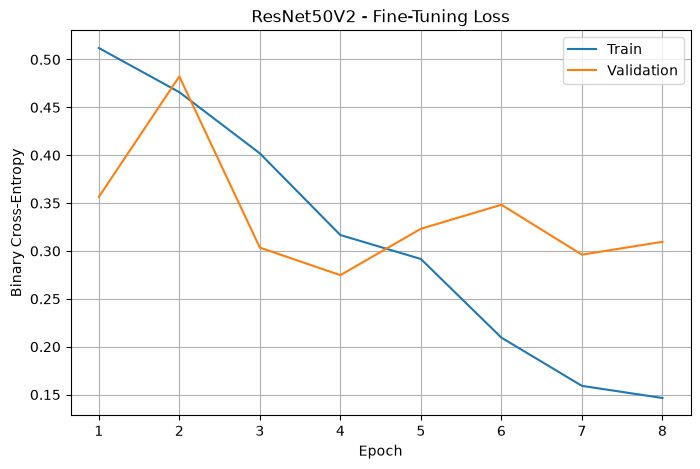

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_finetune_df.index,
    history_finetune_df["loss"],
    label="Train"
)
plt.plot(
    history_finetune_df.index,
    history_finetune_df["val_loss"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy")
plt.title("ResNet50V2 - Fine-Tuning Loss")
plt.legend()
plt.grid(True)
plt.show()

### 21.2. Curva ROC-AUC

Evolución del área bajo la curva ROC durante la fase de Fine-Tuning.

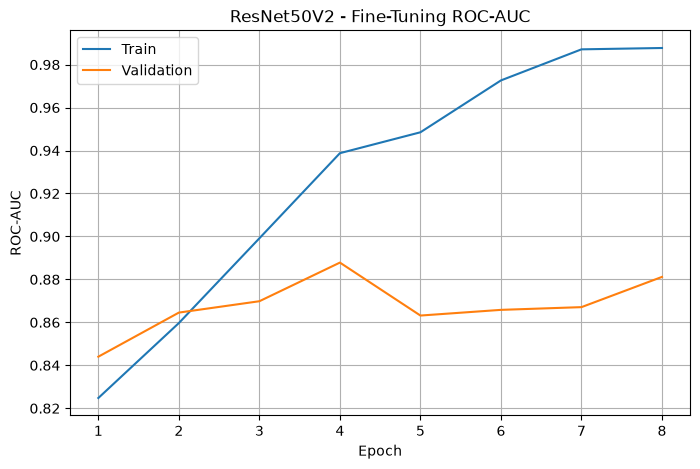

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_finetune_df.index,
    history_finetune_df["roc_auc"],
    label="Train"
)
plt.plot(
    history_finetune_df.index,
    history_finetune_df["val_roc_auc"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("ROC-AUC")
plt.title("ResNet50V2 - Fine-Tuning ROC-AUC")
plt.legend()
plt.grid(True)
plt.show()

### 21.3. Curva PR-AUC

Evolución de la métrica PR-AUC para supervisar la discriminación de la clase minoritaria (HIGH_RISK) durante el ajuste fino.

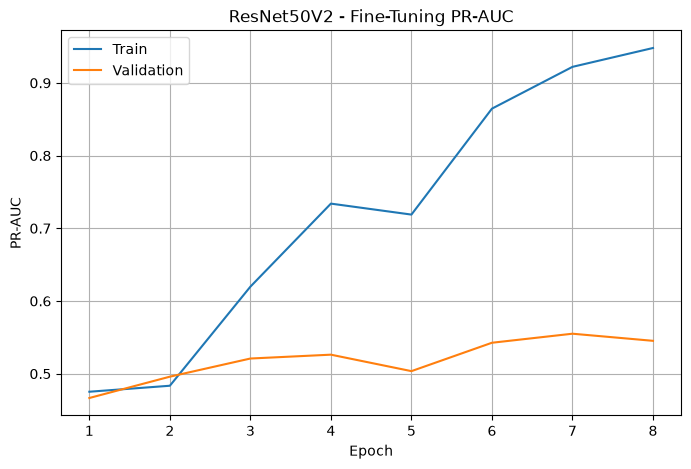

In [6]:
plt.figure(figsize=(8, 5))
plt.plot(
    history_finetune_df.index,
    history_finetune_df["pr_auc"],
    label="Train"
)
plt.plot(
    history_finetune_df.index,
    history_finetune_df["val_pr_auc"],
    label="Validation"
)
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("ResNet50V2 - Fine-Tuning PR-AUC")
plt.legend()
plt.grid(True)
plt.show()

## 22. Comparación Transfer Learning vs Fine-Tuning

Comparación de los mejores checkpoints seleccionados por mínima pérdida
de validación (`val_loss`) en ambas fases de entrenamiento.

In [7]:
best_transfer_idx = (
    history_transfer_df["val_loss"].idxmin()
)
best_finetune_idx = (
    history_finetune_df["val_loss"].idxmin()
)

comparison_df = pd.DataFrame(
    {
        "Transfer Learning": {
            "best_epoch": best_transfer_idx,
            "val_loss": history_transfer_df.loc[
                best_transfer_idx,
                "val_loss"
            ],
            "val_accuracy": history_transfer_df.loc[
                best_transfer_idx,
                "val_accuracy"
            ],
            "val_roc_auc": history_transfer_df.loc[
                best_transfer_idx,
                "val_roc_auc"
            ],
            "val_pr_auc": history_transfer_df.loc[
                best_transfer_idx,
                "val_pr_auc"
            ],
            "val_precision": history_transfer_df.loc[
                best_transfer_idx,
                "val_precision"
            ],
            "val_recall": history_transfer_df.loc[
                best_transfer_idx,
                "val_recall"
            ]
        },
        "Fine-Tuning": {
            "best_epoch": best_finetune_idx,
            "val_loss": history_finetune_df.loc[
                best_finetune_idx,
                "val_loss"
            ],
            "val_accuracy": history_finetune_df.loc[
                best_finetune_idx,
                "val_accuracy"
            ],
            "val_roc_auc": history_finetune_df.loc[
                best_finetune_idx,
                "val_roc_auc"
            ],
            "val_pr_auc": history_finetune_df.loc[
                best_finetune_idx,
                "val_pr_auc"
            ],
            "val_precision": history_finetune_df.loc[
                best_finetune_idx,
                "val_precision"
            ],
            "val_recall": history_finetune_df.loc[
                best_finetune_idx,
                "val_recall"
            ]
        }
    }
)

COMPARISON_PATH = (
    RESULTS_DIR
    / "resnet50v2_comparison.csv"
)
comparison_df.to_csv(
    COMPARISON_PATH
)
print(
    "Comparación guardada en:",
    COMPARISON_PATH
)

display(comparison_df)

Comparación guardada en: /mnt/c/Users/SeuNg720/Documents/TP1-RetiScan/results/glaucoma/resnet50v2/resnet50v2_comparison.csv


,Transfer Learning,Fine-Tuning
best_epoch,6.000000,4.000000
val_loss,0.417704,0.274742
val_accuracy,0.841584,0.900990
val_roc_auc,0.802434,0.887831
val_pr_auc,0.433478,0.526192
val_precision,0.419355,0.666667
val_recall,0.481481,0.518519
